In [147]:
import re
from datetime import datetime
from typing import List, Dict, Any

class Account:
    _account_counter = 1000

    def __init__(self, account_holder: str, balance: float = 0.0):
        if not isinstance(account_holder, str):
            raise ValueError("Имя владельца должно быть строкой")
        if not re.fullmatch(r'^[A-Za-zА-Яа-яЁё]+\s+[A-Za-zА-Яа-яЁё]+$', account_holder):
            raise ValueError("Имя владельца должно быть в формате 'Имя Фамилия' (кириллицей или латиницей)")
        if not all(part[0].isupper() for part in account_holder.split()):
            raise ValueError("Имя и фамилия должны начинаться с заглавной буквы")
        self.holder = account_holder

        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным")
        self._balance = balance

        Account._account_counter += 1
        self.account_number = f"ACC-{Account._account_counter}"

        self.operations_history: List[Dict[str, Any]] = []

        if balance > 0:
            self._record_operation(
                operation_type='init',
                amount=balance,
                status='success'
            )

    def _record_operation(self, operation_type: str, amount: float, status: str):
        record = {
            'type': operation_type,
            'amount': amount,
            'timestamp': datetime.now().isoformat(),
            'balance_after': self._balance if status == 'success' else self._balance,
            'status': status
        }
        self.operations_history.append(record)

    def deposit(self, amount: float):
        if amount < 0:
            self._record_operation(operation_type='deposit', amount=amount, status='fail')
            raise ValueError("Сумма пополнения не может быть отрицательной")
        self._balance += amount
        self._record_operation(operation_type='deposit', amount=amount, status='success')

    def withdraw(self, amount: float):
        if amount < 0:
            self._record_operation(operation_type='withdraw', amount=amount, status='fail')
            raise ValueError("Сумма снятия не может быть отрицательной")
        if amount > self._balance:
            self._record_operation(operation_type='withdraw', amount=amount, status='fail')
            raise ValueError("Недостаточно средств на счёте")
        self._balance -= amount
        self._record_operation(operation_type='withdraw', amount=amount, status='success')

    def get_balance(self) -> float:
        return self._balance

    def get_history(self) -> List[Dict[str, Any]]:
        return self.operations_history.copy()

    def plot_history(self):
        try:
            import pandas as pd
            import matplotlib.pyplot as plt
        except ImportError:
            print("Для визуализации требуются библиотеки: pandas и matplotlib")
            return

        if not self.operations_history:
            print("Нет данных для построения графика")
            return

        successful_ops = [op for op in self.operations_history if op['status'] == 'success']
        if not successful_ops:
            print("Нет успешных операций для отображения")
            return

        df = pd.DataFrame(successful_ops)
        df = df.sort_values('timestamp')  # на всякий случай

        plt.figure(figsize=(10, 6))
        plt.plot(df['timestamp'], df['balance_after'], marker='o', linestyle='-')
        plt.title(f"Изменение баланса счёта {self.account_number}")
        plt.xlabel("Дата и время")
        plt.ylabel("Баланс")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.grid(True)
        plt.show()

Ошибка: Недостаточно средств на счёте
{'type': 'init', 'amount': 1000.0, 'timestamp': '2025-11-05T16:06:31.390270', 'balance_after': 1000.0, 'status': 'success'}
{'type': 'deposit', 'amount': 500, 'timestamp': '2025-11-05T16:06:31.390309', 'balance_after': 1500.0, 'status': 'success'}
{'type': 'withdraw', 'amount': 2000, 'timestamp': '2025-11-05T16:06:31.390347', 'balance_after': 1500.0, 'status': 'fail'}
{'type': 'withdraw', 'amount': 300, 'timestamp': '2025-11-05T16:06:31.390417', 'balance_after': 1200.0, 'status': 'success'}


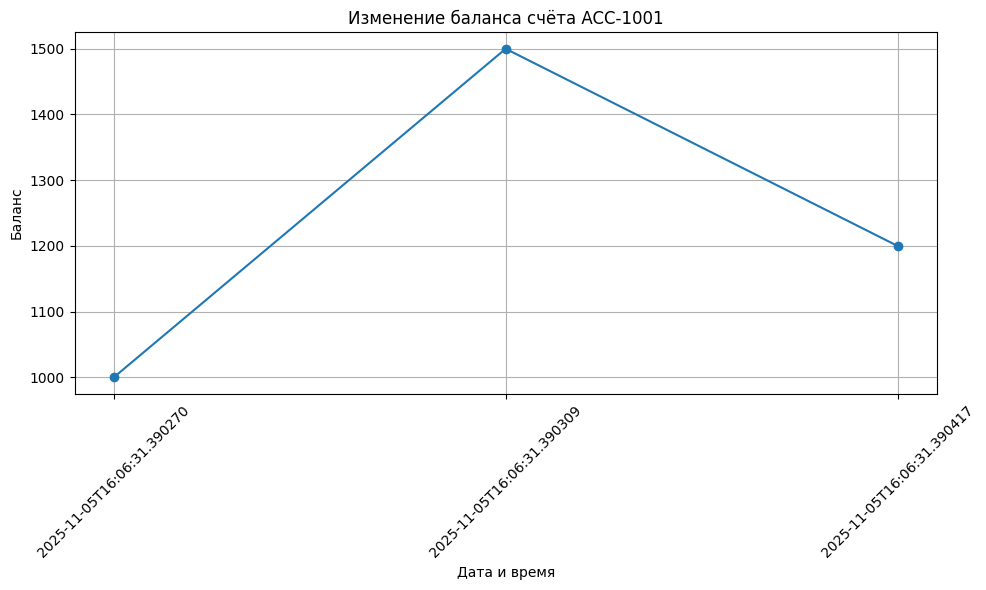

In [148]:
acc = Account("Алексей Петров", 1000.0)

acc.deposit(500)
try:
    acc.withdraw(2000)
except ValueError as e:
    print("Ошибка:", e)

acc.withdraw(300)

for op in acc.get_history():
    print(op)

acc.plot_history()